In [6]:
#4.1
x = [1,2,3,10]
y = [10, 20, 30, 40]

z = [x+y  for x, y in zip(x, y)]

def fun(x, y):
    return x + y

pami = map(fun, x, y)

print(z)
print(list(pami))

[11, 22, 33, 50]
[11, 22, 33, 50]


In [54]:
#4.3
import numpy as np

my = input("r, p, s for rock paper or scissors (lowercase)")
com = (np.random.rand()*3)//1 # generates random pick

cem = 9

if my == 'r': # assigns numer to my pick
    cem = 0
elif my == 'p':
    cem = 1
elif my == 's':
    cem = 2
    

if ((cem == 0 and com == 2) or (cem == 1 and com == 0) or (cem == 2 and com == 1)): # checks for winning
    print("You win!")
elif ((cem == 2 and com == 0)or (cem == 0 and com == 1) or (cem == 1 and com == 2)):
    print("You lose!")
else :
    print("Draw")
    

r, p, s for rock paper or scissors (lowercase)r
You lose!


7.998778225192306


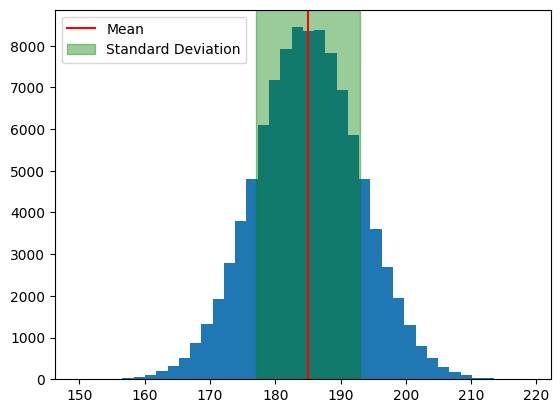

In [69]:
#4.4
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

pepl = np.random.normal(185, 8, 100000)

plt.hist(pepl, 40)

mien = np.mean(pepl)
sand = np.std(pepl)
print(sand)
plt.axvline(x = mien, color = 'r', label = 'Mean')
plt.axvspan(mien-sand, mien+sand, color = "g", alpha=0.4, label='Standard Deviation')
plt.legend()



In [90]:
#4.6
from sympy import symbols, integrate, sympify


integrand = input('enter function: ')
variable = input('enter variable: ')
lower = input('input lower: ')
upper = input('input upper: ')

x = symbols(variable)
expr = sympify(integrand)
integral = integrate(expr, (x, lower, upper))

print(integral)

#change

enter function: x
enter variable: x
input lower: 1
input upper: 2
3/2


(6.123233995736766e-17+1j) 1.0
-4.0 3.0000000000000004


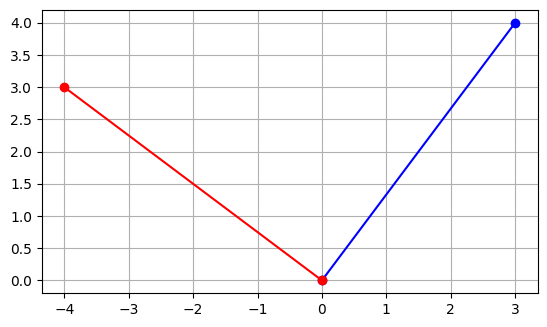

In [95]:
#4.12
import numpy as np
import math

theta = math.radians(90)
rotor = np.cos(theta) + 1j*np.sin(theta)
print(rotor, abs(rotor))

z = 3 + 4j
zr = rotor * z
xr = zr.real
yr = zr.imag
print(xr, yr)

from matplotlib import pyplot as plt
plt.plot([0,3], [0,4], color='b', marker='o')
plt.plot([0,xr], [0,yr], color='r', marker='o')
plt.gca().set_aspect(1)
plt.grid()
plt.show()

In [71]:
#4.14
import numpy as np
def func_filter(func,seq):
    res = []
    myseq = []
    if type(seq) == int:
        myseq.append(seq)
    else: 
        myseq = seq
    for i in myseq:
        if i > 0:
            res.append(i)
    return func(res)

sq = np.array([-100, -10, 0, 10, 100])
result = func_filter(np.log10, sq)
print("Result log10:", result)



Result log10: [1. 2.]
Result log10: [2.]


In [109]:
seq = 100
seq = np.asarray(seq)
seq = seq[seq>0]
print(seq)

seq = [-100, -10, 0, 10, 100]
seq = np.asarray(seq)
seq = seq[seq>0]
print(seq)

[100]
[ 10 100]


In [110]:
#4.16
from astropy.cosmology import Planck18
from astropy import units as u
import numpy as np
import scipy

H0 = Planck18.H0.value
Om0 = Planck18.Om0
Ode0 = Planck18.Ode0

def aicz(zed):
    rut = Om0*((1+zed)**3)+Ode0
    return (H0*np.sqrt(rut))

def inter(grate):
    return 1/((1+grate)*(aicz(grate)))

def tl(zedd):
    tim, _ = scipy.integrate.quad(inter, 0, zedd)
    return tim

final = (tl(2)*u.Mpc * u.s/u.km).to(u.Gyr)

print(final)



10.526203408163191 Gyr


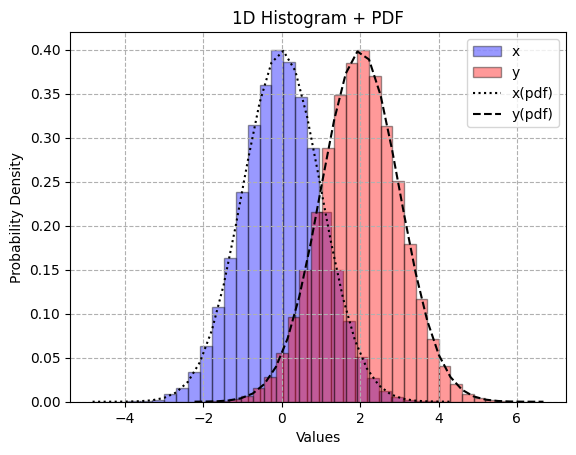

In [50]:
#4.21
import matplotlib.pyplot as plt
import matplotlib.axes as ax
import numpy as np
from scipy.stats import norm

x = np.random.normal(0, 1, 100000)
y = np.random.normal(2, 1, 100000)

plt.figure(0)
xcount, xbins, _ = plt.hist(x, 30, density=True, label="x", alpha=0.4, color="blue", edgecolor='black')
ycount, ybins, _ = plt.hist(y, 30, density=True, label='y', alpha=0.4, color='red', edgecolor='black')
plt.plot(xbins, norm.pdf(xbins, 0, 1),'k:', label='x(pdf)')
plt.plot(ybins, norm.pdf(ybins, 2, 1),'k--' , label='y(pdf)')
plt.grid(True, linestyle='--')
plt.xlabel('Values')
plt.ylabel('Probability Density')
plt.title('1D Histogram + PDF')
plt.legend()

plt.show()


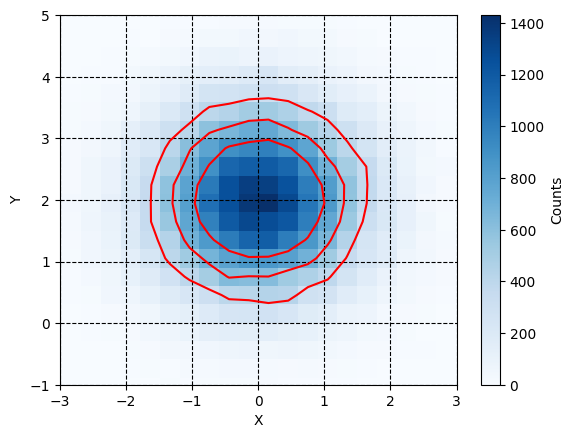

In [67]:
import numpy as np
import matplotlib.pyplot as plt

# Generate sample data
np.random.seed(42)
x = np.random.normal(0, 1, 100000)
y = np.random.normal(2, 1, 100000)

levels = [0.5, 0.2, 0.1]
labels = ['1σ', '2σ', '3σ']

# Compute 2D histogram
H, xedges, yedges = np.histogram2d(x, y, bins=30)

def fmt(x, pos):
    idx = np.argmin(np.abs(used_levels - x))
    return labels[idx]

# Compute the mean and standard deviation of the histogram
mean = np.mean(H)
std = np.std(H)

# Create the plot
fig, ax = plt.subplots()

# Plot the 2D histogram
pc = ax.pcolormesh(xedges, yedges, H.T, cmap=plt.cm.Blues)


# Overlay contour lines at 1, 2, and 3 standard deviations
contour = ax.contour(xedges[:-1] + np.diff(xedges)/2,
                     yedges[:-1] + np.diff(yedges)/2,
                     H.T, levels=[mean + i*std for i in [1, 2, 3]],
                     colors='red', linestyles='solid')

# Add labels and colorbar
ax.set_xlabel('X')
ax.set_ylabel('Y')
fig.colorbar(pc, ax=ax, label='Counts')
ax.set_xlim(-3, 3)
ax.set_ylim(-1, 5) 




# Add contour labels
plt.grid(linestyle='--', color='black')
plt.show()